In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data = pd.read_csv("social_anxiety_dataset.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1968 non-null   float64
 1   Gender                             1911 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        1994 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           1936 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   int64  
 7   Smoking                            1924 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   int64  
 10  Heart Rate (bpm)                   2030 non-null   int64  
 11  Breathing Rate (breaths/min)       2030 non-null   int64

In [4]:
num_data = ["Age",
"Sleep Hours",
"Physical Activity (hrs/week)",
"Caffeine Intake (mg/day)",
"Alcohol Consumption (drinks/week)",
"Stress Level (1-10)", "Heart Rate (bpm)",
"Breathing Rate (breaths/min)",
"Sweating Level (1-5)",
"Therapy Sessions (per month)",
"Diet Quality (1-10)",
"Anxiety Level (1-10)"]
cat_data = ["Gender", "Occupation", "Smoking", "Family History of Anxiety", "Dizziness", "Medication",
            "Recent Major Life Event", "Therapy History", "Target", "is_Anxious"
            ]

In [25]:
def box_plot_out(df:pd.DataFrame, col:str):

    # در این تابع باکس پلات ستون های عددی نمایش داده می شود و تعداد موارد خارج از محدوده مشخص می شود
    # برای وروردی col یک ستون عددی باید وارد شود


    fig, ax = plt.subplots(figsize=(15,4))


    # box plot
    q1, q3 = np.percentile(df[col].dropna(), [25, 75])
    iqr = q3 - q1

    l_bound = q1 - 1.5 * iqr
    u_bound = q3 + 1.5 * iqr

    num_lower = (df[col] < l_bound).sum()
    num_upper = (df[col] > u_bound).sum()


    sns.boxplot(x=df[col], boxprops={"facecolor":"lightgray"})
    ax.set_title("Boxplot")
    ax.text(s=f"number of upper outlier: {num_upper}", x=0.85, y=0.9, transform=ax.transAxes, bbox=dict(facecolor='red', alpha=0.5))
    ax.text(s=f"number of lower outlier: {num_lower}", x=0.1, y=0.9, transform=ax.transAxes, bbox=dict(facecolor='red', alpha=0.5))
    ax.set_facecolor("#FFFFFF")
    fig.patch.set_facecolor('#E6E6FA')
    plt.show()


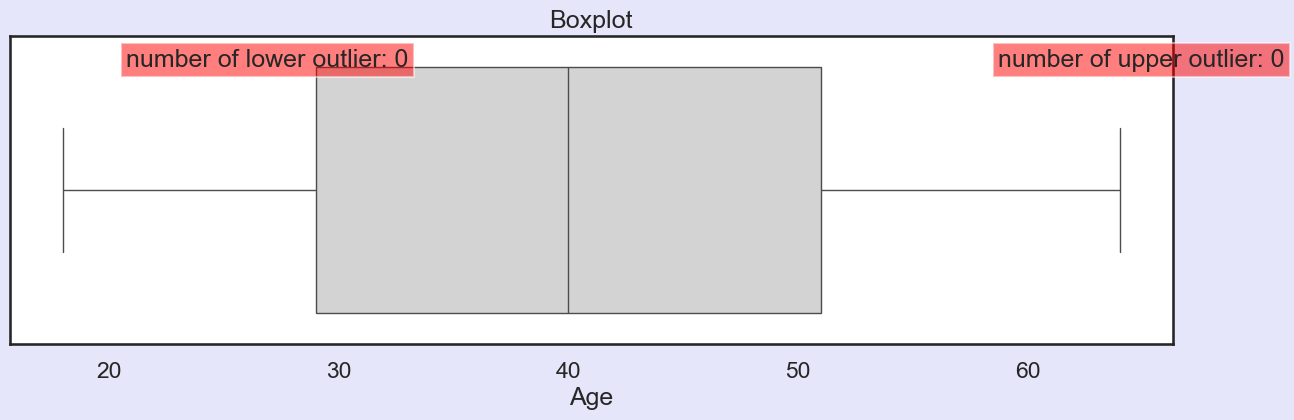

In [28]:
box_plot_out(data, "Age")

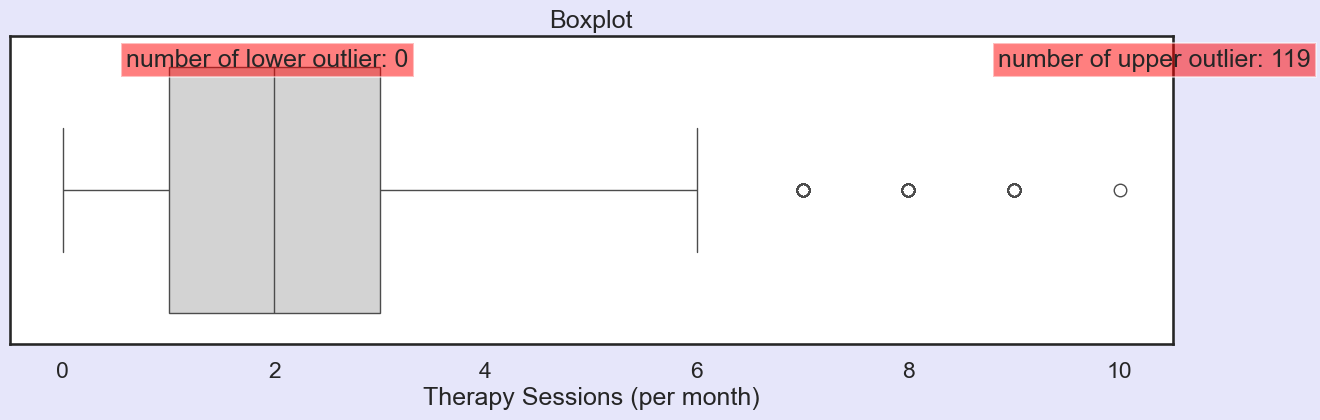

In [29]:
box_plot_out(data, "Therapy Sessions (per month)")

<Axes: xlabel='Age', ylabel='Sleep Hours'>

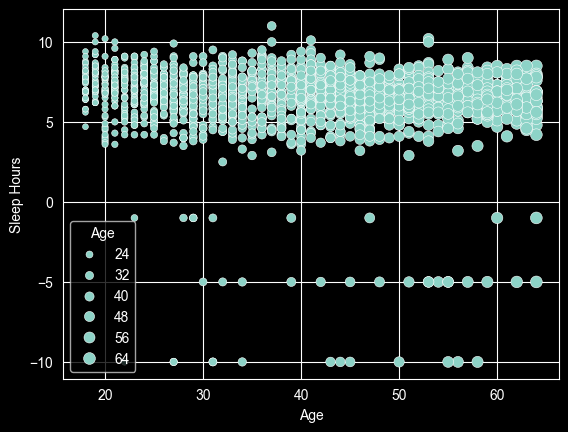

In [74]:
sns.scatterplot(
    data=data,
    x="Age",
    y="Sleep Hours",
    # hue="Gender",
    size="Age"
)

In [34]:
def bar_plot_cat(df, col):
    fig, ax = plt.subplots(1, 3, figsize=(20,5))
    sns.set_theme(context="talk", style="white")
    sns.countplot(df, x=col, hue="is_Anxious", palette="Set1", ax=ax[1])
    sns.barplot(df, x=col, y="is_Anxious", estimator=sum, errorbar=None, ax=ax[0])
    conti_tabel = pd.crosstab(df[col], df["is_Anxious"], normalize="index")
    conti_tabel.plot(kind="bar", stacked=True, ax=ax[2])
    ax[0].tick_params(axis="x", labelrotation=90)
    ax[1].tick_params(axis="x", labelrotation=90)
    ax[2].tick_params(axis="x", labelrotation=90)

    plt.show()



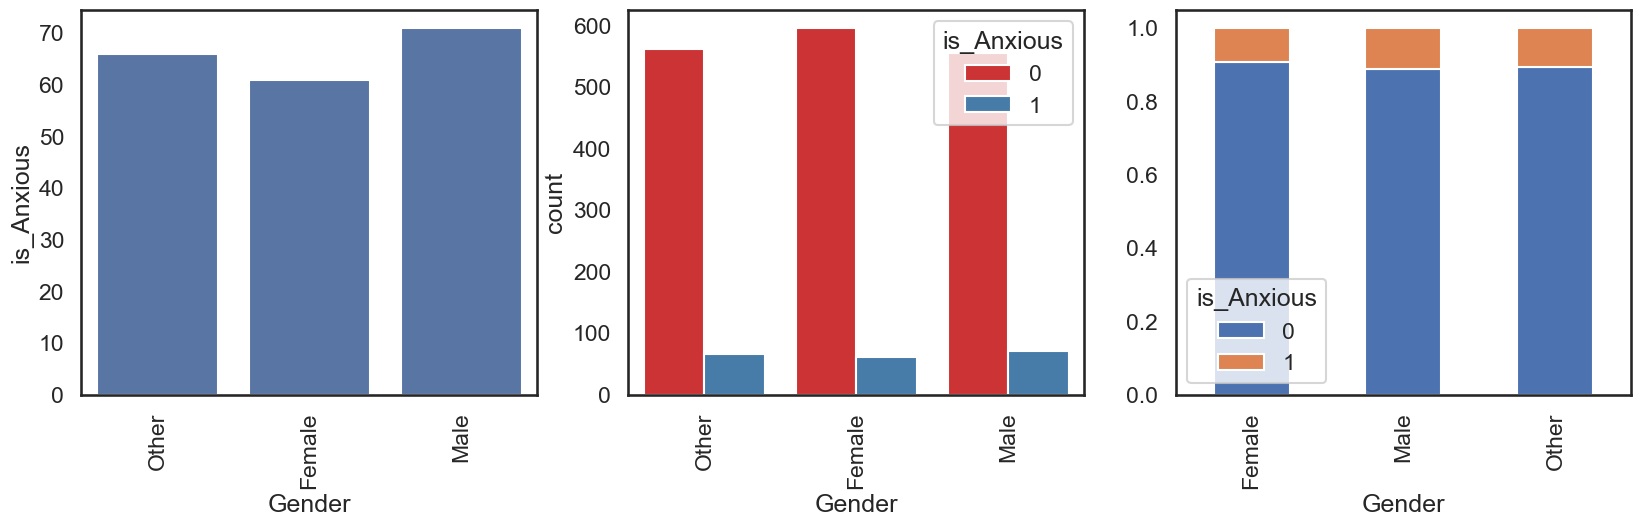

In [47]:
bar_plot_cat(data, "Gender")

<Axes: xlabel='is_Anxious', ylabel='Smoking'>

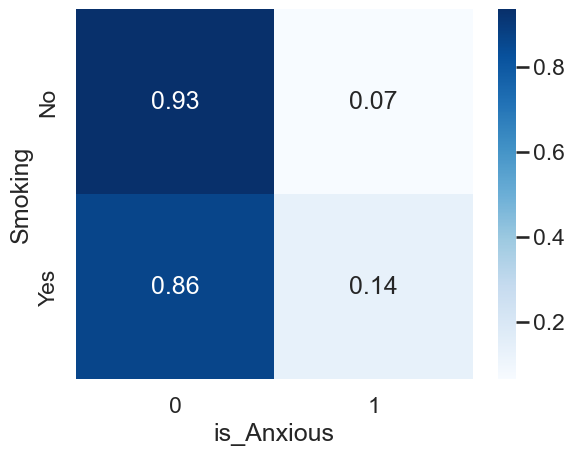

In [134]:
conti_tabel = pd.crosstab(data["Smoking"], data["is_Anxious"], normalize="index")
sns.heatmap(conti_tabel, annot=True, fmt=".2f", cmap="Blues")


In [51]:
def heat_cat_plot(col:str):
    fig, ax = plt.subplots(1, 3, figsize=(20,5))

    percent_cont_table = pd.crosstab(data[col], columns="percent", normalize=True)*100
    sns.heatmap(percent_cont_table, annot=True, ax=ax[0], cbar=False)

    conti_tabel = pd.crosstab(data[col].dropna(), data["is_Anxious"])
    sns.heatmap(conti_tabel, annot=True, cmap="Blues", ax=ax[1], cbar=False)

    por_conti_tabel = pd.crosstab(data[col], data["is_Anxious"], normalize="index")
    sns.heatmap(por_conti_tabel, annot=True, fmt=".2f", cmap="Blues", ax=ax[2], cbar=False)


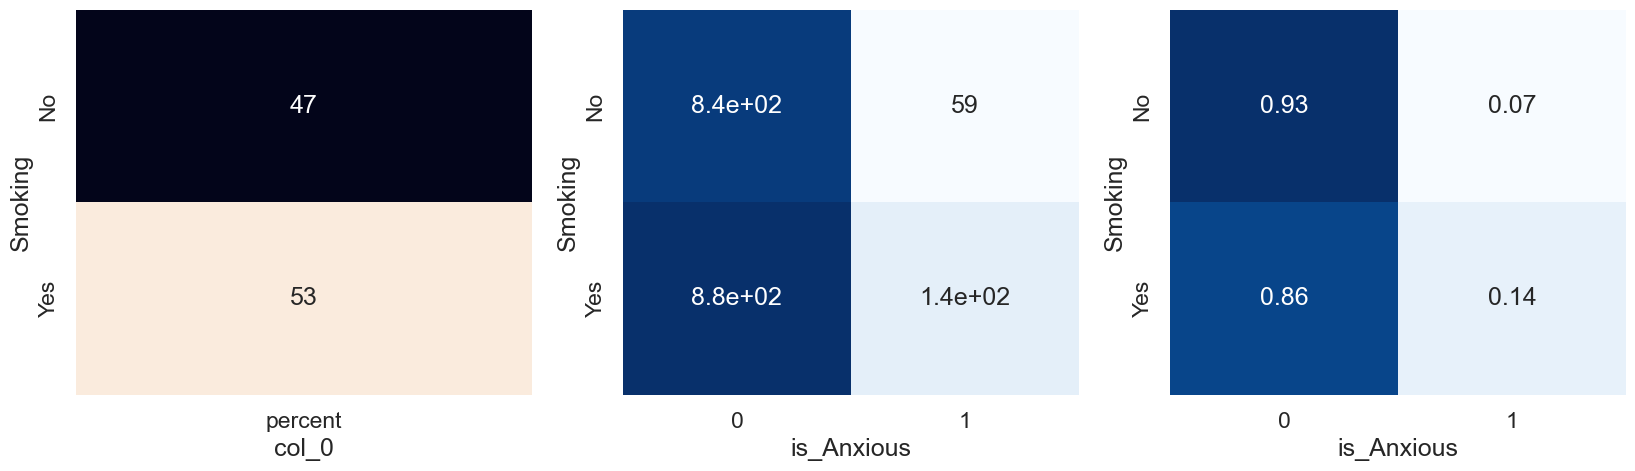

In [52]:
heat_cat_plot("Smoking")

<Axes: xlabel='Sleep Hours', ylabel='Count'>

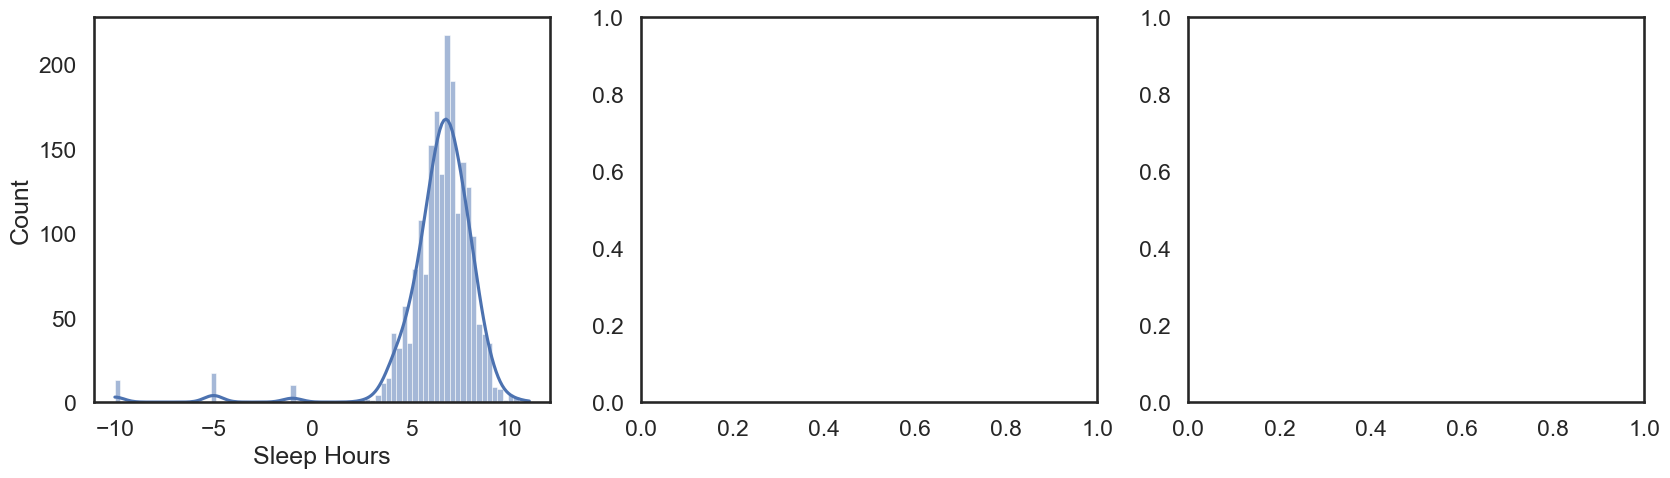

In [139]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))



In [142]:
def hist_plot(col):
    sns.histplot(data[col], kde=True)

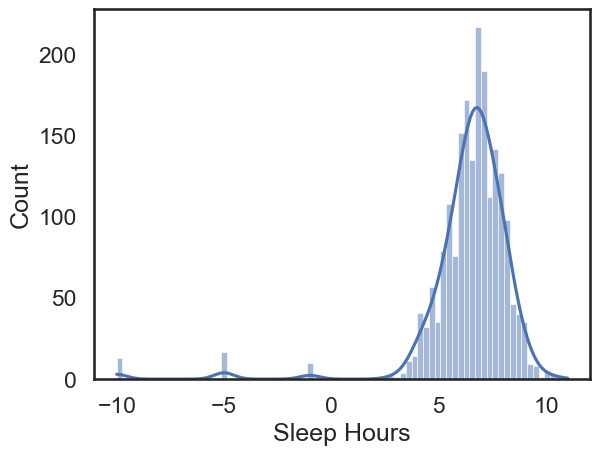

In [171]:
hist_plot("Sleep Hours")

In [145]:
(osm, osr), (slope, intercept, r) = stats.probplot(data["Sleep Hours"], dist="norm")

In [146]:
scatter(osm, osr, color="gray", alpha=0.7)

NameError: name 'scatter' is not defined

In [147]:
def plot_distribution(df, cols=None, ncols=2, figsize_per_plot=(5, 4)):
    """
    برای هر ستون عددی: هیستوگرام + KDE
    """
    if cols is None:
        cols = df.select_dtypes(include='number').columns.tolist()

    n = len(cols)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0] * ncols,
                                                     figsize_per_plot[1] * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'Distribution: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

    # محور اضافه رو مخفی کن
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Numerical Columns', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

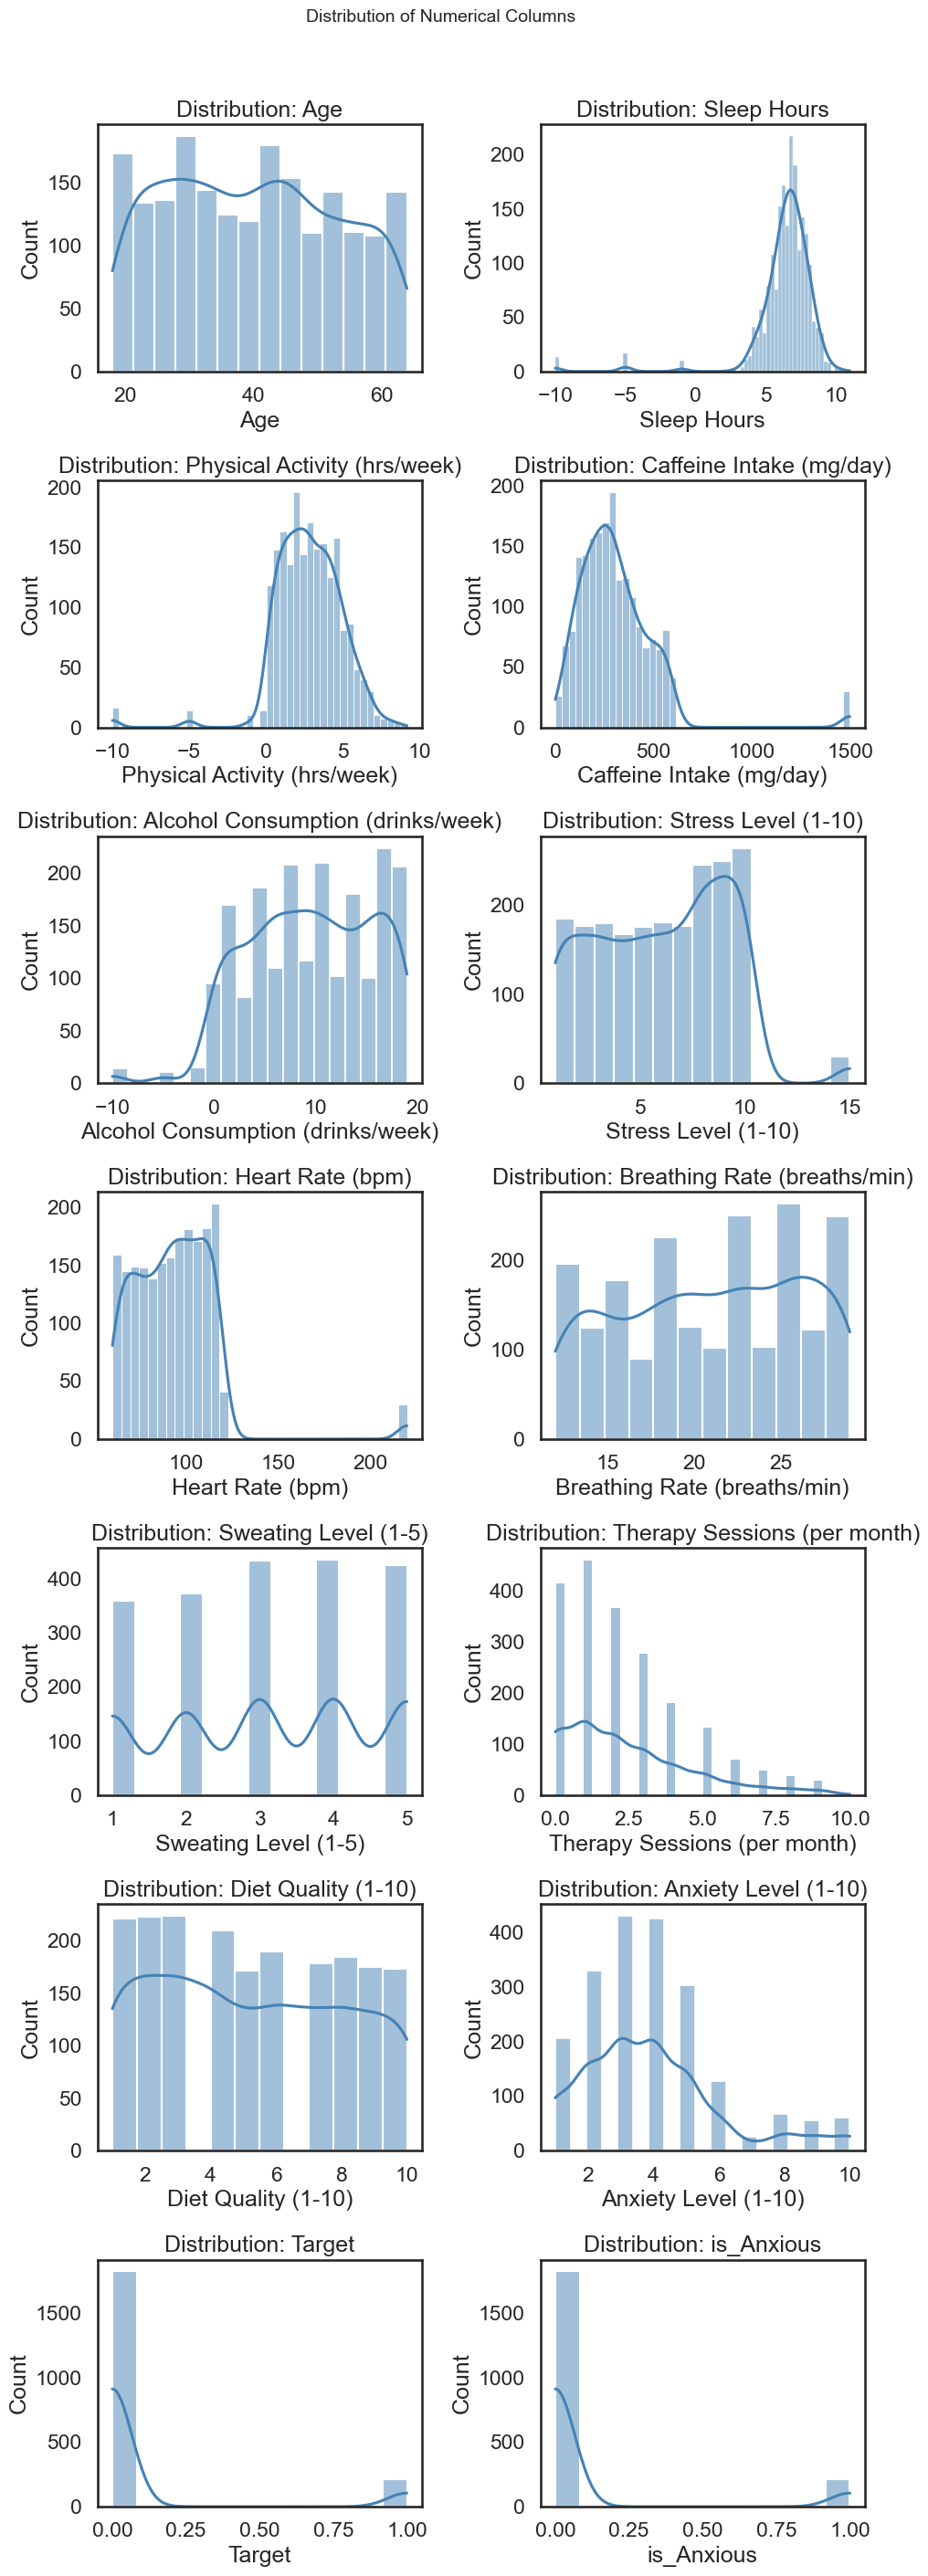

In [150]:
plot_distribution(data)

In [154]:
cor_matrix

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious
Age,1.000000,-0.116165,0.052121,-0.025911,-0.028814,-0.006491,-0.031260,-0.047241,-0.012095,-0.094665,0.063480,-0.077147,-0.120175,-0.120175
Sleep Hours,-0.116165,1.000000,0.082116,-0.092395,-0.045187,-0.083552,-0.048214,-0.075197,-0.045140,-0.161286,0.101838,-0.285676,-0.308173,-0.308173
Physical Activity (hrs/week),0.052121,0.082116,1.000000,-0.106297,-0.048316,-0.076485,-0.021698,-0.049411,-0.067318,-0.154759,0.087586,-0.195623,-0.253675,-0.253675
Caffeine Intake (mg/day),-0.025911,-0.092395,-0.106297,1.000000,0.005777,0.106905,-0.008831,0.056524,0.030614,0.166792,-0.070256,0.272357,0.283058,0.283058
Alcohol Consumption (drinks/week),-0.028814,-0.045187,-0.048316,0.005777,1.000000,0.049500,0.027642,0.026408,0.054058,0.077035,-0.050534,0.081590,0.111394,0.111394
Stress Level (1-10),-0.006491,-0.083552,-0.076485,0.106905,0.049500,1.000000,0.031995,0.054550,0.085892,0.180385,-0.109449,0.618896,0.330058,0.330058
Heart Rate (bpm),-0.031260,-0.048214,-0.021698,-0.008831,0.027642,0.031995,1.000000,0.026176,0.029009,0.110427,-0.061387,0.119276,0.151154,0.151154
Breathing Rate (breaths/min),-0.047241,-0.075197,-0.049411,0.056524,0.026408,0.054550,0.026176,1.000000,0.053576,0.108009,-0.053662,0.163555,0.197089,0.197089
Sweating Level (1-5),-0.012095,-0.045140,-0.067318,0.030614,0.054058,0.085892,0.029009,0.053576,1.000000,0.121934,-0.109974,0.151369,0.182311,0.182311
Therapy Sessions (per month),-0.094665,-0.161286,-0.154759,0.166792,0.077035,0.180385,0.110427,0.108009,0.121934,1.000000,-0.150787,0.529424,0.603598,0.603598


In [157]:
data[num_data]

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10)
0,59.0,7.0,2.4,40.0,5,4,79,21,5,0,1.0,2.0
1,46.0,5.1,5.4,156.0,11,3,70,19,4,2,1.0,4.0
2,40.0,5.1,1.9,570.0,14,9,101,23,3,6,4.0,9.0
3,40.0,7.6,0.9,129.0,0,9,116,16,2,2,2.0,6.0
4,26.0,6.7,3.0,64.0,13,15,119,19,4,0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025,42.0,3.7,2.9,113.0,18,4,89,19,4,1,2.0,3.0
2026,34.0,8.4,2.0,239.0,14,7,83,15,2,0,5.0,4.0
2027,62.0,6.1,1.6,149.0,18,2,77,26,5,4,8.0,1.0
2028,47.0,6.3,1.1,298.0,-1,7,63,27,2,1,3.0,4.0


In [160]:
data[cat_data]

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event,Therapy History
0,Other,Teacher,Yes,No,No,No,Yes,Group Therapy
1,Female,Student,NaN,No,Yes,No,No,NaN
2,Other,Lawyer,Yes,Yes,No,No,Yes,NaN
3,Male,Nurse,No,No,No,NaN,No,NaN
4,Male,Other,No,No,No,Yes,Yes,NaN
...,...,...,...,...,...,...,...,...
2025,Male,Teacher,Yes,Yes,No,Yes,Yes,NaN
2026,Other,Freelancer,No,No,No,Yes,No,No previous history
2027,Female,Musician,Yes,No,No,No,Yes,NaN
2028,Other,Nurse,No,Yes,Yes,Yes,Yes,NaN


In [167]:
cor = data[num_data].corr(method="spearman", numeric_only=True)

<Axes: >

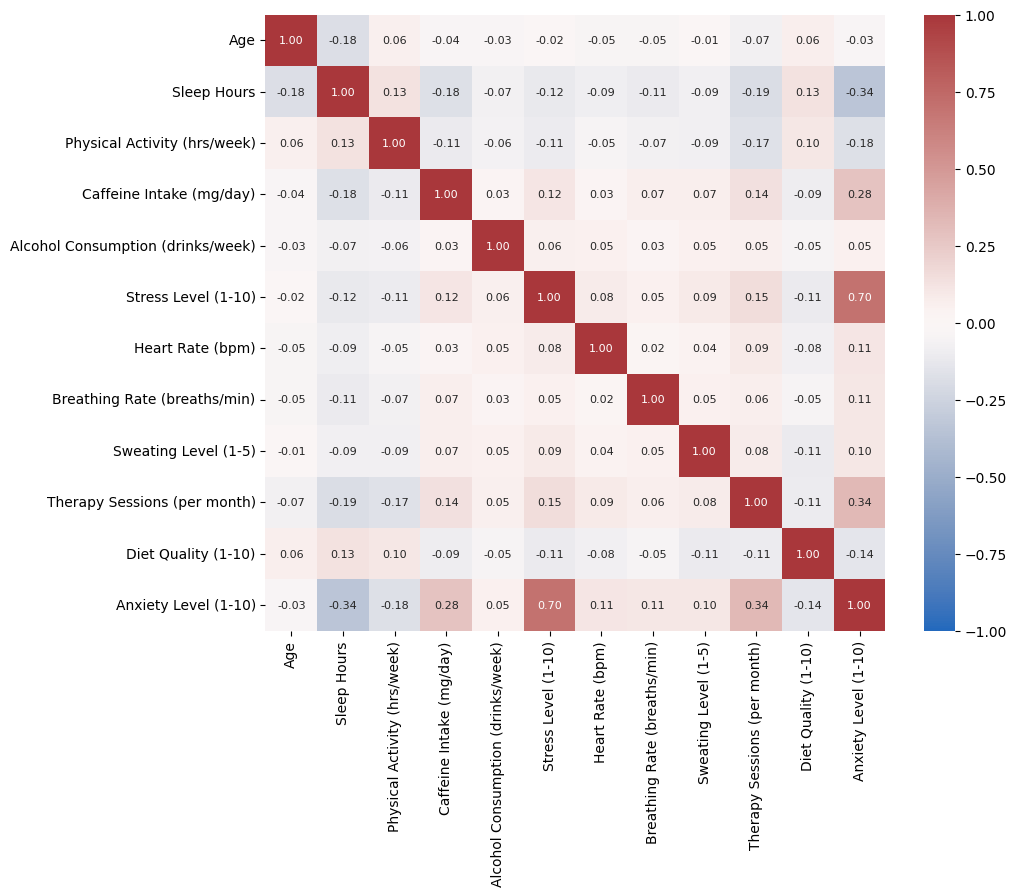

In [176]:
plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0, annot_kws={"size": 8})

In [181]:
def corr_heatmap(numeric_cols, method="spearman"):
    cor = numeric_cols.corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0, annot_kws={"size": 8})
    plt.title(f"Correlation Heatmap: {method}")

    plt.tight_layout()
    plt.show()


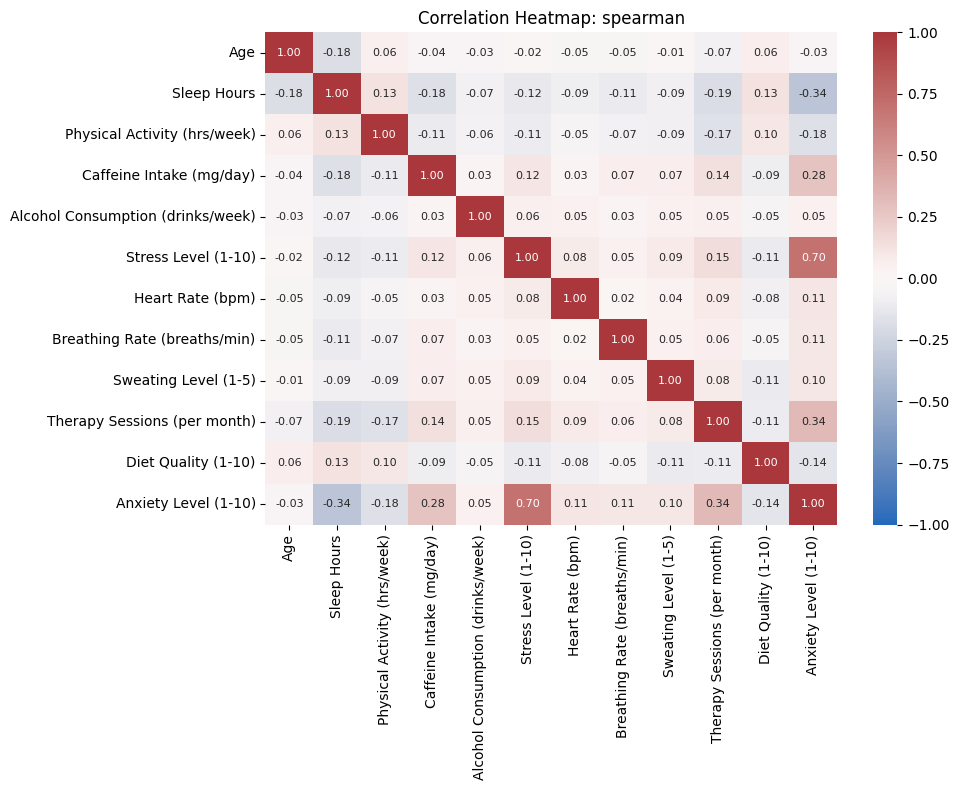

In [182]:
corr_heatmap(data[num_data])

<Axes: >

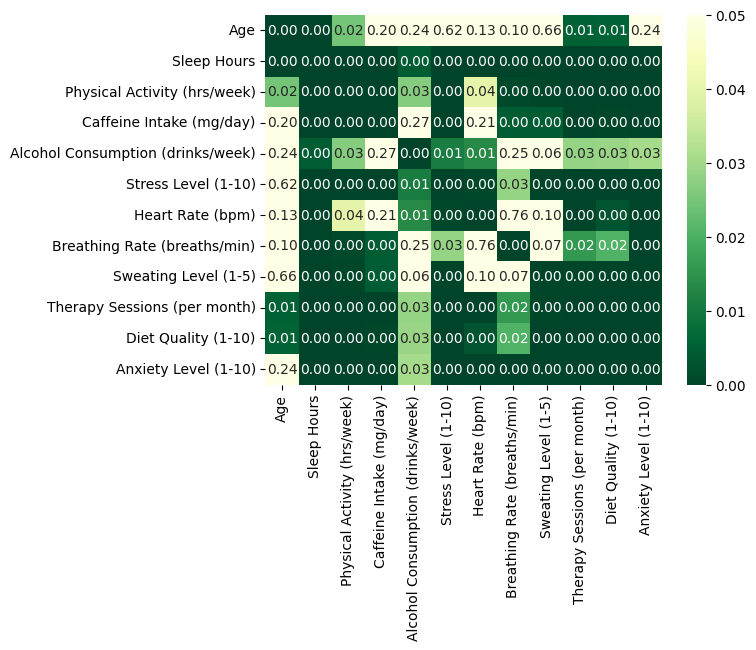

In [188]:
from scipy.stats import spearmanr, pearsonr

corr, pval = spearmanr(data[num_data].dropna())

p_matrix = pd.DataFrame(pval, index=num_data, columns=num_data)

sns.heatmap(
        p_matrix,
        annot=True,
        fmt=".2f",
        cmap="YlGn_r",
        vmin=0,
        vmax=0.05,
    )


In [205]:
def pvalue_heatmap(num_cols, method="spearmanr"):
    from scipy.stats import spearmanr, pearsonr

    if method == "spearmanr":
        corr, pval = spearmanr(num_cols.dropna())
    else:
        corr, pval = pearsonr(data["Age"], data["Stress Level (1-10)"])

    p_matrix = pd.DataFrame(pval, index=num_data, columns=num_data)
    plt.figure(figsize=(10, 8))

    sns.heatmap(p_matrix, annot=True, fmt=".2f", cmap="YlGn_r", vmin=0, vmax=0.05, annot_kws={"size": 8})
    plt.title(f"P_value Correlation Heatmap: {method}")

    plt.tight_layout()
    plt.show()


In [206]:
pvalue_heatmap(data[num_data], method="pearsonr")

ValueError: DataFrame constructor not properly called!